## Bhawandeep Kaur

## RAG End-to-End - All Steps, Context Flow, and Equations

This notebook is a **from-scratch RAG simulator**. It helps you understand the full RAG pipeline and where production systems become hard.

---

### 0) What problem RAG solves

A base language model answers from internal training knowledge only.
RAG adds an external knowledge source and forces answers to be grounded in retrieved context.

High-level pipeline:

1. **Ingest documents**
2. **Chunk + index**
3. **Retrieve candidates for a query**
4. **Rank/rerank**
5. **Build context window**
6. **Generate answer with citations**
7. **Evaluate quality + latency**

---

### 1) Indexing phase (offline)

Given document set $D = \{d_1, d_2, \dots, d_n\}$:

- Split each document into chunks $c_i$
- Build searchable representation for each chunk

In this notebook, representation is lexical (tokens + index), not dense embedding vectors.

Tokenization concept:

$$
\text{tokens}(x) = [w_1, w_2, ..., w_m]
$$

Inverted index concept:

$$
I[w] = \{i \mid w \in c_i\}
$$

This is exactly what your `tokenize()` + index-building cells do.

---

### 2) Retrieval phase (online)

For user query $q$:

- Convert query to representation
- Compare with each candidate chunk
- Return top-$k$ chunks

#### 2.1 Lexical score (implemented)

A simple overlap score:

$$
\text{lexical}(q, c_i) = \sum_{w \in q} \mathbf{1}[w \in c_i]
$$

#### 2.2 Cosine similarity (the standard dense retrieval equation)

If vectors existed, we would use:

$$
\cos(\theta) = \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}
$$

This notebook explains it conceptually, but intentionally avoids external embedding APIs.

---

### 3) Ranking / scoring pipeline

In real systems, final relevance is multi-signal. A common pattern:

$$
\text{score}(c_i) = \alpha\,s_{\text{lex}} + \beta\,s_{\text{dense}} + \gamma\,s_{\text{fresh}} + \delta\,s_{\text{meta}} + \epsilon\,s_{\text{rerank}}
$$

In this notebook, your toy pipeline uses:

$$
\text{score}(c_i) = 0.75\cdot \text{lexical}(q,c_i) + 0.25\cdot \text{freshness}(c_i)
$$

with freshness decay:

$$
\text{freshness}(d) = \frac{1}{1 + \frac{\text{days\_old}}{20}}
$$

This models your **relevance + freshness** tradeoff.

---

### 4) Context construction (grounding)

After ranking, choose top-$k$ chunks $R_k$ and build a grounded context:

$$
R_k = \operatorname{TopK}(\{(c_i, \text{score}(c_i))\}, k)
$$

Prompt context idea:

$$
\text{context} = c_{(1)} \oplus c_{(2)} \oplus \cdots \oplus c_{(k)}
$$

where $\oplus$ means concatenation.

In your notebook, `generate_with_citations()` returns:

- answer text built from retrieved snippets
- source IDs as citations
- measured latency

So answers are explicitly **grounded** in retrieved context.

---

### 5) Generation phase

General RAG objective:

$$
\hat{y} = \arg\max_y\; P(y\mid q, R_k)
$$

In this notebook (no external LLM), generation is rule/template-based string composition. That is deliberate for learning mechanics.

---

### 6) Evaluation dimensions (what matters in production)

For production RAG, optimize both quality and systems behavior:

- **Relevance**: Are retrieved chunks actually on-topic?
- **Groundedness**: Does answer stay within context?
- **Noise control**: Are irrelevant chunks filtered out?
- **Freshness**: Are newer facts preferred when needed?
- **Latency**: Is $p95$ response time acceptable?
- **Citation traceability**: Can each claim map to a source?

Example retrieval metric:

$$
\text{Precision@k} = \frac{\#(\text{relevant chunks in top-k})}{k}
$$

---

### 7) Mapping theory to THIS notebook

- **Indexing**: dataset + tokenization + inverted index cells
- **Retrieval**: `search()` and `retrieve()`
- **Scoring**: TF-IDF bonus + `search_with_pipeline_score()`
- **Grounding**: `generate_with_citations()`
- **Observability**: latency measurement + score charts

So this notebook gives you a strong conceptual path:

**Keyword IR → weighted ranking → grounded generation → quality/latency analysis**

before moving to dense embeddings + real LLMs.

---

### 8) One-line truth (your point, precisely)

In real deployments, model quality helps — but RAG success is often dominated by **retrieval/ranking pipeline quality under latency constraints**.

In [14]:
# Imports (keep all imports at the top)
import math
import time
from dataclasses import dataclass, field
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional, Any

# optional plotting library for memory usage visualisation
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    plt = None
    MATPLOTLIB_AVAILABLE = False

print("Imports ready. matplotlib:", MATPLOTLIB_AVAILABLE)

Imports ready. matplotlib: True


In [15]:
# sample documents for demonstration
docs = [
    "RAG stands for Retrieval Augmented Generation",
    "It combines retrieval systems with language models",
    "Cosine similarity is used in vector search",
    "Transformers use attention mechanisms",
    "FAISS is a vector search library",
]

for i, d in enumerate(docs):
    print(i, d)

0 RAG stands for Retrieval Augmented Generation
1 It combines retrieval systems with language models
2 Cosine similarity is used in vector search
3 Transformers use attention mechanisms
4 FAISS is a vector search library


## Step 2 — Tokenization

In [16]:
def tokenize(text):
    # lowercase, strip basic punctuation, split on whitespace
    cleaned = text.lower()
    for ch in [".", ",", "?", "!", ";", ":", "(", ")"]:
        cleaned = cleaned.replace(ch, "")
    return cleaned.split()

tokenize("What is RAG, really?")

['what', 'is', 'rag', 'really']

## Step 3 — Build Inverted Index

Maps each word -> list of document IDs containing it.

In [17]:
# map from word to list of doc ids where it appears
index = {}
for i, doc in enumerate(docs):
    for word in tokenize(doc):
        if word not in index:
            index[word] = []
        if i not in index[word]:
            index[word].append(i)

for w, ids in list(index.items())[:10]:
    print(w, '->', ids)

rag -> [0]
stands -> [0]
for -> [0]
retrieval -> [0, 1]
augmented -> [0]
generation -> [0]
it -> [1]
combines -> [1]
systems -> [1]
with -> [1]


## Step 4 — Query Search (Keyword Scoring)

In [18]:
# simple search function that counts word matches
def search(query):
    words = tokenize(query)
    scores = [0] * len(docs)
    for word in words:
        if word in index:
            for doc_id in index[word]:
                scores[doc_id] += 1
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return [(docs[i], s) for i, s in ranked if s > 0]

search("vector search")

[('Cosine similarity is used in vector search', 2),
 ('FAISS is a vector search library', 2)]

## Step 5 — Retrieve Top-K

In [19]:
def retrieve(query, k=2):
    return [doc for doc, _ in search(query)[:k]]

retrieve("What is RAG", k=2)

['RAG stands for Retrieval Augmented Generation',
 'Cosine similarity is used in vector search']

## Step 6 — Template-Based Generation

In [20]:
def generate(query, k=2):
    context = retrieve(query, k=k)
    if not context:
        return "I don't know based on the available documents."
    return f"Q: {query}\nA (based on docs): " + " | ".join(context)

## Step 7 — Try It

In [21]:
queries = [
    "What is RAG",
    "Tell me about vector search",
    "How do transformers work",
    "What is quantum computing",  # not in docs
]

for q in queries:
    print(generate(q))
    print('-' * 60)

Q: What is RAG
A (based on docs): RAG stands for Retrieval Augmented Generation | Cosine similarity is used in vector search
------------------------------------------------------------
Q: Tell me about vector search
A (based on docs): Cosine similarity is used in vector search | FAISS is a vector search library
------------------------------------------------------------
Q: How do transformers work
A (based on docs): Transformers use attention mechanisms
------------------------------------------------------------
Q: What is quantum computing
A (based on docs): Cosine similarity is used in vector search | FAISS is a vector search library
------------------------------------------------------------


## Bonus — TF-IDF Scoring (still no libraries)

A small upgrade: rare words count more than common ones.

In [22]:
N = len(docs)
tokenized_docs = [tokenize(d) for d in docs]

# document frequency
df = {}
for tokens in tokenized_docs:
    for w in set(tokens):
        df[w] = df.get(w, 0) + 1
# function to compute TF-IDF scores for a query
def tfidf_score(query):
    q_tokens = tokenize(query)
    scores = [0.0] * N
    for i, tokens in enumerate(tokenized_docs):
        for w in q_tokens:
            tf = tokens.count(w)
            if tf == 0 or w not in df:
                continue
            idf = math.log((N + 1) / (df[w] + 1)) + 1
            scores[i] += tf * idf
    # rank documents by score
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return [(docs[i], round(s, 3)) for i, s in ranked if s > 0]

tfidf_score("vector search library")

[('FAISS is a vector search library', 5.485),
 ('Cosine similarity is used in vector search', 3.386)]

## Limitations

- No semantic similarity (`car` ≠ `automobile`).
- No reasoning or abstraction.
- Generation is just string concatenation.

**Next step:** build a mini embedding model from word co-occurrence to simulate vector semantics — still without libraries.

## Production RAG Reality Check (What this notebook covers)

Your point is exactly right: production RAG is mostly an **IR + ranking + systems** problem.

This notebook now covers simplified versions of:

- Retrieval relevance scoring (keyword / TF-IDF style)
- Freshness weighting (newer docs get a small boost)
- Grounding + citation tracing (answer includes source IDs)
- Low-noise controls (metadata filtering)
- Pipeline scoring (combine multiple signals)
- Basic latency measurement (`time.perf_counter`)

Still *not* covered (by design):

- True semantic embeddings and vector similarity
- Hybrid dense+sparse search at scale
- Learned rerankers / cross-encoders
- Distributed indexing and serving under strict SLOs

So yes: this is a **learning-grade RAG simulator** that mirrors production concepts, but not production neural quality.

In [23]:
# richer docs with metadata so we can simulate production signals
docs_meta = [
    {
        "id": "doc-1",
        "text": "RAG stands for Retrieval Augmented Generation",
        "topic": "rag-basics",
        "days_old": 120,
    },
    {
        "id": "doc-2",
        "text": "Chunking strategy directly impacts retrieval quality and context precision",
        "topic": "chunking",
        "days_old": 15,
    },
    {
        "id": "doc-3",
        "text": "Hybrid search combines sparse lexical signals with dense vector signals",
        "topic": "retrieval",
        "days_old": 30,
    },
    {
        "id": "doc-4",
        "text": "Reranking improves top results by re-scoring candidates with deeper matching",
        "topic": "ranking",
        "days_old": 8,
    },
    {
        "id": "doc-5",
        "text": "Metadata filters can reduce noise by restricting source type and time window",
        "topic": "grounding",
        "days_old": 3,
    },
]


def freshness_boost(days_old):
    # very simple decay-like rule in [~0.14, 1.0]
    return 1.0 / (1.0 + days_old / 20.0)

# combined scoring function that incorporates multiple signals with simple weights
def search_with_pipeline_score(query, topic_filter=None, max_days_old=None, k=3):
    t0 = time.perf_counter()
    q_tokens = tokenize(query)

    candidates = []
    for d in docs_meta:
        if topic_filter and d["topic"] != topic_filter:
            continue
        if max_days_old is not None and d["days_old"] > max_days_old:
            continue

        d_tokens = tokenize(d["text"])
        # lexical relevance signal (simple term overlap)
        lexical = sum(1 for w in q_tokens if w in d_tokens)  
        # freshness signal
        fresh = freshness_boost(d["days_old"])               

        # weighted pipeline score (toy version of multi-signal ranking)
        score = 0.75 * lexical + 0.25 * fresh

        if score > 0:
            candidates.append({
                "id": d["id"],
                "text": d["text"],
                "topic": d["topic"],
                "days_old": d["days_old"],
                "score": round(score, 4),
            })

    ranked = sorted(candidates, key=lambda x: x["score"], reverse=True)[:k]
    latency_ms = (time.perf_counter() - t0) * 1000
    return ranked, round(latency_ms, 3)

# final generation function that includes citations and latency info
def generate_with_citations(query, **filters):
    ranked, latency_ms = search_with_pipeline_score(query, **filters)
    if not ranked:
        return {
            "answer": "I don't know based on filtered documents.",
            "citations": [],
            "latency_ms": latency_ms,
        }

    snippets = [r["text"] for r in ranked]
    citations = [r["id"] for r in ranked]
    answer = "Based on retrieved context: " + " | ".join(snippets)

    return {
        "answer": answer,
        "citations": citations,
        "latency_ms": latency_ms,
    }

# usage of the final generation function with filters to reduce noise and improve relevance
result = generate_with_citations(
    "How to reduce retrieval noise and improve ranking",
    max_days_old=45,
    k=3,
)
result

{'answer': 'Based on retrieved context: Metadata filters can reduce noise by restricting source type and time window | Chunking strategy directly impacts retrieval quality and context precision | Reranking improves top results by re-scoring candidates with deeper matching',
 'citations': ['doc-5', 'doc-2', 'doc-4'],
 'latency_ms': 0.02}

### Mapping to your production checklist

- **Semantically relevant**: only approximated via lexical overlap (not true semantics).
- **Fresh**: modeled via `days_old` freshness boost.
- **Grounded**: answer is built only from retrieved text.
- **Low-noise**: modeled via topic/time metadata filters.
- **Latency constraints**: measured per query in milliseconds.
- **Chunking / embedding / hybrid / rerank / citation tracing**:
  - chunking: discussed conceptually (you can simulate by splitting docs)
  - embedding/hybrid/rerank: acknowledged as missing in strict no-library mode
  - citation tracing: included with source IDs in output

If you want, I can next add **manual chunking + overlap simulation** in one more cell (still pure Python).

## Step 8 — Plots and Charts (minimal dependency)

Scoring rows:
{'id': 'doc-5', 'topic': 'grounding', 'lexical': 2, 'freshness': 0.8696, 'score': 1.7174}
{'id': 'doc-2', 'topic': 'chunking', 'lexical': 1, 'freshness': 0.5714, 'score': 0.8929}
{'id': 'doc-4', 'topic': 'ranking', 'lexical': 0, 'freshness': 0.7143, 'score': 0.1786}
{'id': 'doc-3', 'topic': 'retrieval', 'lexical': 0, 'freshness': 0.4, 'score': 0.1}


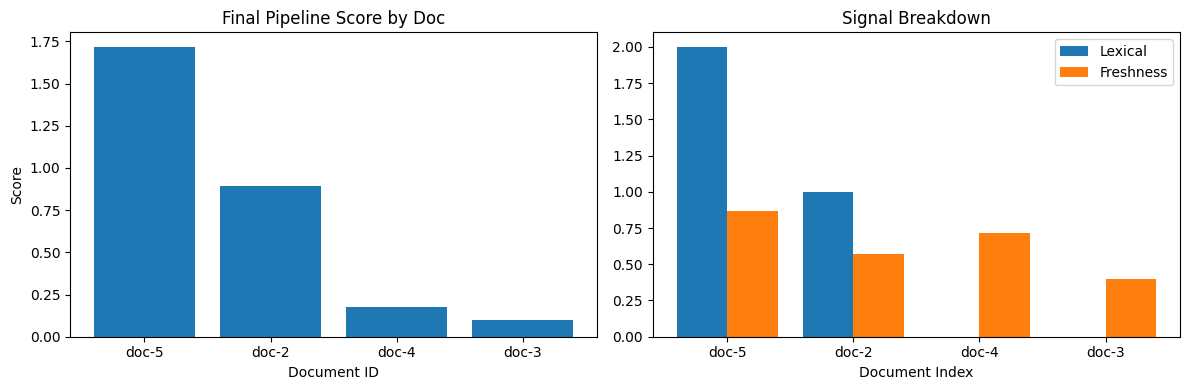

In [ ]:
def scoring_breakdown(query, topic_filter=None, max_days_old=None):
    q_tokens = tokenize(query)
    rows = []

    for d in docs_meta:
        if topic_filter and d["topic"] != topic_filter:
            continue
        if max_days_old is not None and d["days_old"] > max_days_old:
            continue

        d_tokens = tokenize(d["text"])
        lexical = sum(1 for w in q_tokens if w in d_tokens)
        fresh = freshness_boost(d["days_old"])
        score = 0.75 * lexical + 0.25 * fresh

        rows.append({
            "id": d["id"],
            "topic": d["topic"],
            "lexical": lexical,
            "freshness": round(fresh, 4),
            "score": round(score, 4),
        })

    rows.sort(key=lambda x: x["score"], reverse=True)
    return rows


def ascii_bar_chart(labels, values, width=40, title="ASCII Chart"):
    max_v = max(values) if values else 1
    print("\n" + title)
    print("-" * (width + 20))
    for label, v in zip(labels, values):
        n = int((v / max_v) * width) if max_v else 0
        print(f"{label:10} | {'' * n} {v:.3f}")


query_for_chart = "improve retrieval ranking reduce noise"
rows = scoring_breakdown(query_for_chart, max_days_old=90)

labels = [r["id"] for r in rows]
scores = [r["score"] for r in rows]
lexicals = [r["lexical"] for r in rows]
freshness_vals = [r["freshness"] for r in rows]

print("Scoring rows:")
for r in rows:
    print(r)

if MATPLOTLIB_AVAILABLE and plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # final pipeline score
    axes[0].bar(labels, scores)
    axes[0].set_title("Final Pipeline Score by Doc")
    axes[0].set_xlabel("Document ID")
    axes[0].set_ylabel("Score")

    # signal comparison
    x = range(len(labels))
    axes[1].bar([i - 0.2 for i in x], lexicals, width=0.4, label="Lexical")
    axes[1].bar([i + 0.2 for i in x], freshness_vals, width=0.4, label="Freshness")
    axes[1].set_title("Signal Breakdown")
    axes[1].set_xlabel("Document Index")
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(labels)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("\nmatplotlib unavailable, using pure-Python ASCII chart fallback.")
    ascii_bar_chart(labels, scores, title="Final Pipeline Score")
    ascii_bar_chart(labels, lexicals, title="Lexical Signal")
    ascii_bar_chart(labels, freshness_vals, title="Freshness Signal")

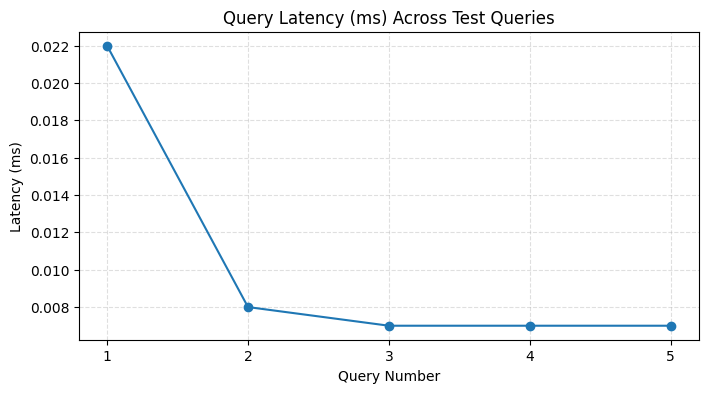

In [25]:
# Optional: latency chart across multiple queries
latency_queries = [
    "what is rag",
    "hybrid retrieval",
    "reduce retrieval noise",
    "fresh grounded citation",
    "ranking strategy",
]

latencies = []
for q in latency_queries:
    _, latency_ms = search_with_pipeline_score(q, max_days_old=120, k=3)
    latencies.append(latency_ms)

if MATPLOTLIB_AVAILABLE and plt is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(latency_queries) + 1), latencies, marker="o")
    plt.title("Query Latency (ms) Across Test Queries")
    plt.xlabel("Query Number")
    plt.ylabel("Latency (ms)")
    plt.xticks(range(1, len(latency_queries) + 1))
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()
else:
    ascii_bar_chart(
        [f"q{i}" for i in range(1, len(latency_queries) + 1)],
        latencies,
        title="Latency per Query (ms)",
    )

## Step 9 — Senior-Style OOP RAG Architecture

This section rewrites the pipeline using classes/objects and cleaner separation of concerns:

- `Document`: immutable data model for chunks
- `SimpleTokenizer`: text normalization/token splitting
- `InvertedIndexStore`: indexing + document frequency stats
- `ScoreConfig`: configurable ranking weights
- `AdvancedRanker`: multi-signal ranking (lexical + tf-idf + freshness)
- `RAGEngine`: orchestration (retrieve, generate, cite, profile)

Design goals:

- composable components
- explicit data contracts
- easy extension for production features (dense retriever, reranker, filters)
- deterministic and testable behavior

Answer:
 Based on retrieved context: Metadata filters can reduce noise by restricting source type and time window | Chunking strategy directly impacts retrieval quality and context precision | Reranking improves top results by re-scoring candidates with deeper matching

Citations: ['doc-5', 'doc-2', 'doc-4']
Latency (ms): 0.026

Ranking details:
{'doc_id': 'doc-5', 'topic': 'grounding', 'lexical': 3.0, 'tfidf': 5.8904, 'freshness': 0.8696, 'final_score': 3.6921}
{'doc_id': 'doc-2', 'topic': 'chunking', 'lexical': 2.0, 'tfidf': 3.3863, 'freshness': 0.5714, 'final_score': 2.2709}
{'doc_id': 'doc-4', 'topic': 'ranking', 'lexical': 0.0, 'tfidf': 0.0, 'freshness': 0.7143, 'final_score': 0.1071}


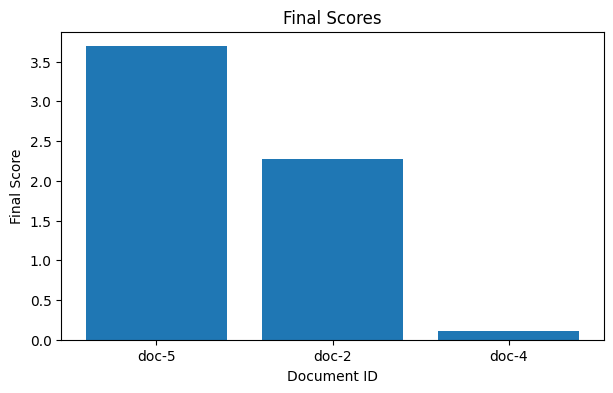

In [26]:
# for the advanced OOP version, we will define classes for Document, InvertedIndexStore, Ranker, and RAGEngine.
@dataclass(frozen=True)
class Document:
    id: str
    text: str
    topic: str = "general"
    days_old: int = 0

# configuration class to hold scoring weights for different signals
@dataclass
class ScoreConfig:
    w_lexical: float = 0.5
    w_tfidf: float = 0.35
    w_freshness: float = 0.15

# ranked result class to hold detailed scoring breakdown for each retrieved document
@dataclass
class RankedResult:
    doc: Document
    lexical: float
    tfidf: float
    freshness: float
    final_score: float

# simple tokenizer that lowercases and removes basic punctuation for consistent tokenization
class SimpleTokenizer:
    def __init__(self, extra_punct: Optional[List[str]] = None):
        self.punct = [".", ",", "?", "!", ";", ":", "(", ")"]
        if extra_punct:
            self.punct.extend(extra_punct)

    def tokenize(self, text: str) -> List[str]:
        cleaned = text.lower()
        for ch in self.punct:
            cleaned = cleaned.replace(ch, "")
        return cleaned.split()

# inverted index store that holds documents and allows efficient retrieval based on token matches and document frequencies
class InvertedIndexStore:
    def __init__(self, tokenizer: SimpleTokenizer):
        self.tokenizer = tokenizer
        self.documents: List[Document] = []
        self.index: Dict[str, List[int]] = defaultdict(list)
        self.df: Dict[str, int] = {}
        self.doc_tokens: List[List[str]] = []
    # method to add documents to the store and update the inverted index and document frequencies
    def add_documents(self, docs_input: List[Document]) -> None:
        for doc in docs_input:
            doc_idx = len(self.documents)
            self.documents.append(doc)
            tokens = self.tokenizer.tokenize(doc.text)
            self.doc_tokens.append(tokens)

            for w in set(tokens):
                self.index[w].append(doc_idx)

        self._recompute_df()
    # internal method to recompute document frequencies based on the current set of documents and their tokens
    def _recompute_df(self) -> None:
        df_counter: Counter = Counter()
        for tokens in self.doc_tokens:
            for w in set(tokens):
                df_counter[w] += 1
        self.df = dict(df_counter)
    # property to get the current number of documents in the store
    @property
    def size(self) -> int:
        return len(self.documents)

# advanced ranker that computes a combined score based on lexical overlap, TF-IDF, and freshness signals, with configurable weights
class AdvancedRanker:
    def __init__(self, store: InvertedIndexStore, config: ScoreConfig):
        self.store = store
        self.config = config
    # static method to compute a freshness score based on the age of the document, with a simple decay function
    @staticmethod
    def freshness(days_old: int) -> float:
        return 1.0 / (1.0 + days_old / 20.0)
    # method to compute a lexical relevance score based on the count of query tokens that appear in the document tokens
    def _lexical_score(self, q_tokens: List[str], d_tokens: List[str]) -> float:
        return float(sum(1 for w in q_tokens if w in d_tokens))
    # method to compute a TF-IDF score for the document based on the query tokens, using term frequency and inverse document frequency
    def _tfidf_score(self, q_tokens: List[str], d_tokens: List[str]) -> float:
        n_docs = max(self.store.size, 1)
        score = 0.0
        for w in q_tokens:
            tf = d_tokens.count(w)
            if tf == 0:
                continue
            df = self.store.df.get(w, 0)
            idf = math.log((n_docs + 1) / (df + 1)) + 1
            score += tf * idf
        return score
    # main ranking method that processes the query, applies optional filters, 
    # computes scores for each document, and returns the top-k ranked results with detailed scoring breakdown
    def rank(
        self,
        query: str,
        top_k: int = 3,
        topic_filter: Optional[str] = None,
        max_days_old: Optional[int] = None,
    ) -> List[RankedResult]:
        q_tokens = self.store.tokenizer.tokenize(query)
        results: List[RankedResult] = []

        for i, doc in enumerate(self.store.documents):
            if topic_filter and doc.topic != topic_filter:
                continue
            if max_days_old is not None and doc.days_old > max_days_old:
                continue

            d_tokens = self.store.doc_tokens[i]
            lex = self._lexical_score(q_tokens, d_tokens)
            tfidf = self._tfidf_score(q_tokens, d_tokens)
            fresh = self.freshness(doc.days_old)

            final = (
                self.config.w_lexical * lex
                + self.config.w_tfidf * tfidf
                + self.config.w_freshness * fresh
            )

            if final > 0:
                results.append(
                    RankedResult(
                        doc=doc,
                        lexical=round(lex, 4),
                        tfidf=round(tfidf, 4),
                        freshness=round(fresh, 4),
                        final_score=round(final, 4),
                    )
                )

        results.sort(key=lambda r: r.final_score, reverse=True)
        return results[:top_k]

# RAG engine that uses the advanced ranker to retrieve relevant documents and generate an answer with citations and latency information
class RAGEngine:
    def __init__(self, ranker: AdvancedRanker):
        self.ranker = ranker

    def answer(
        self,
        query: str,
        top_k: int = 3,
        topic_filter: Optional[str] = None,
        max_days_old: Optional[int] = None,
    ) -> Dict[str, Any]:
        t0 = time.perf_counter()

        ranked = self.ranker.rank(
            query=query,
            top_k=top_k,
            topic_filter=topic_filter,
            max_days_old=max_days_old,
        )

        latency_ms = (time.perf_counter() - t0) * 1000

        if not ranked:
            return {
                "query": query,
                "answer": "I don't know based on current filtered context.",
                "citations": [],
                "latency_ms": round(latency_ms, 3),
                "ranking": [],
            }

        context_snippets = [r.doc.text for r in ranked]
        citations = [r.doc.id for r in ranked]

        return {
            "query": query,
            "answer": "Based on retrieved context: " + " | ".join(context_snippets),
            "citations": citations,
            "latency_ms": round(latency_ms, 3),
            "ranking": [
                {
                    "doc_id": r.doc.id,
                    "topic": r.doc.topic,
                    "lexical": r.lexical,
                    "tfidf": r.tfidf,
                    "freshness": r.freshness,
                    "final_score": r.final_score,
                }
                for r in ranked
            ],
        }


advanced_docs = [
    Document("doc-1", "RAG stands for Retrieval Augmented Generation", "rag-basics", 120),
    Document("doc-2", "Chunking strategy directly impacts retrieval quality and context precision", "chunking", 15),
    Document("doc-3", "Hybrid search combines sparse lexical signals with dense vector signals", "retrieval", 30),
    Document("doc-4", "Reranking improves top results by re-scoring candidates with deeper matching", "ranking", 8),
    Document("doc-5", "Metadata filters can reduce noise by restricting source type and time window", "grounding", 3),
]

advanced_tokenizer = SimpleTokenizer()
advanced_store = InvertedIndexStore(tokenizer=advanced_tokenizer)
advanced_store.add_documents(advanced_docs)

advanced_config = ScoreConfig(w_lexical=0.5, w_tfidf=0.35, w_freshness=0.15)
advanced_ranker = AdvancedRanker(store=advanced_store, config=advanced_config)
advanced_rag = RAGEngine(ranker=advanced_ranker)

advanced_output = advanced_rag.answer(
    query="improve retrieval ranking and reduce noise",
    top_k=3,
    max_days_old=90,
)

print("Answer:\n", advanced_output["answer"])
print("\nCitations:", advanced_output["citations"])
print("Latency (ms):", advanced_output["latency_ms"])
print("\nRanking details:")
for row in advanced_output["ranking"]:
    print(row)

# Optional chart for advanced final scores
if MATPLOTLIB_AVAILABLE and plt is not None and advanced_output["ranking"]:
    ids = [r["doc_id"] for r in advanced_output["ranking"]]
    vals = [r["final_score"] for r in advanced_output["ranking"]]

    plt.figure(figsize=(7, 4))
    plt.bar(ids, vals)
    plt.title("Final Scores")
    plt.xlabel("Document ID")
    plt.ylabel("Final Score")
    plt.show()